## Food Vision Big Transfer Learning with TensorFlow

#### We're going to be building Food Vision Big™, using all of the data from the Food101 dataset.

Yep. All 75,750 training images and 25,250 testing images.

And guess what...this time we've got the goal of beating DeepFood, a 2016 paper which used a Convolutional Neural Network trained for 2-3 days to achieve 77.4% top-1 accuracy.

#### Preliminaries

In [8]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [9]:
import tensorflow as tf

print(tf.__version__)

2.18.0


Download the `helper_functions.py` script...

In [10]:
!wget https://raw.githubusercontent.com/ROARMarketingConcepts/Tensorflow-Deep-Learning/refs/heads/main/extras/helper_functions.py

--2025-03-08 19:10:11--  https://raw.githubusercontent.com/ROARMarketingConcepts/Tensorflow-Deep-Learning/refs/heads/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py.1’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0s      

2025-03-08 19:10:11 (69.4 MB/s) - ‘helper_functions.py.1’ saved [10246/10246]



In [11]:
from helper_functions import *

#### We will leverage pre-trained models in `tf.keras.applications` to apply to image classification use cases.

#### Let's get the data from TensorFlow datasets.

In [12]:
import tensorflow_datasets as tfds

dataset_list = tfds.list_builders()
print("food101" in dataset_list)

True


#### Let's get familiar with the input data

In [13]:
(train_data, test_data), ds_info = tfds.load(name="food101",
                                             split=["train", "validation"],
                                             shuffle_files=True,
                                             as_supervised=True,
                                             with_info=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...:   0%|          | 0/75750 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.RZKU5W_2.0.0/food101-train.tfrecord*...:   0%|         …

Generating validation examples...:   0%|          | 0/25250 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.RZKU5W_2.0.0/food101-validation.tfrecord*...:   0%|    …

Dataset food101 downloaded and prepared to /root/tensorflow_datasets/food101/2.0.0. Subsequent calls will reuse this data.


In [15]:
ds_info

tfds.core.DatasetInfo(
    name='food101',
    full_name='food101/2.0.0',
    description="""
    This dataset consists of 101 food categories, with 101'000 images. For each class, 250 manually reviewed test images are provided as well as 750 training images. On purpose, the training images were not cleaned, and thus still contain some amount of noise. This comes mostly in the form of intense colors and sometimes wrong labels. All images were rescaled to have a maximum side length of 512 pixels.
    """,
    homepage='https://data.vision.ee.ethz.ch/cvl/datasets_extra/food-101/',
    data_dir=PosixGPath('/tmp/tmp0c580amhtfds'),
    file_format=tfrecord,
    download_size=4.65 GiB,
    dataset_size=4.77 GiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=101),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    splits={
        'train': <SplitInfo num_examp

In [16]:
ds_info.features

FeaturesDict({
    'image': Image(shape=(None, None, 3), dtype=uint8),
    'label': ClassLabel(shape=(), dtype=int64, num_classes=101),
})

In [17]:
ds_info.features["label"].names

['apple_pie',
 'baby_back_ribs',
 'baklava',
 'beef_carpaccio',
 'beef_tartare',
 'beet_salad',
 'beignets',
 'bibimbap',
 'bread_pudding',
 'breakfast_burrito',
 'bruschetta',
 'caesar_salad',
 'cannoli',
 'caprese_salad',
 'carrot_cake',
 'ceviche',
 'cheesecake',
 'cheese_plate',
 'chicken_curry',
 'chicken_quesadilla',
 'chicken_wings',
 'chocolate_cake',
 'chocolate_mousse',
 'churros',
 'clam_chowder',
 'club_sandwich',
 'crab_cakes',
 'creme_brulee',
 'croque_madame',
 'cup_cakes',
 'deviled_eggs',
 'donuts',
 'dumplings',
 'edamame',
 'eggs_benedict',
 'escargots',
 'falafel',
 'filet_mignon',
 'fish_and_chips',
 'foie_gras',
 'french_fries',
 'french_onion_soup',
 'french_toast',
 'fried_calamari',
 'fried_rice',
 'frozen_yogurt',
 'garlic_bread',
 'gnocchi',
 'greek_salad',
 'grilled_cheese_sandwich',
 'grilled_salmon',
 'guacamole',
 'gyoza',
 'hamburger',
 'hot_and_sour_soup',
 'hot_dog',
 'huevos_rancheros',
 'hummus',
 'ice_cream',
 'lasagna',
 'lobster_bisque',
 'lobster

#### Let's look at one sample of the training data

In [18]:
train_one_sample = train_data.take(1)
train_one_sample

<_TakeDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [19]:
for image, label in train_one_sample:
  print(f"Image shape: {image.shape}")
  print(f"Image dtype: {image.dtype}")
  print(f"Target class from Food101 dataset: {label}")

Image shape: (341, 512, 3)
Image dtype: <dtype: 'uint8'>
Target class from Food101 dataset: 98


In [20]:
image, label

(<tf.Tensor: shape=(341, 512, 3), dtype=uint8, numpy=
 array([[[  2,   2,   0],
         [  2,   2,   0],
         [  2,   2,   0],
         ...,
         [  0,   3,   0],
         [  0,   4,   0],
         [  0,   4,   0]],
 
        [[  2,   2,   0],
         [  2,   2,   0],
         [  3,   3,   1],
         ...,
         [  1,   3,   0],
         [  0,   4,   0],
         [  0,   4,   0]],
 
        [[  5,   6,   1],
         [  5,   6,   1],
         [  5,   6,   1],
         ...,
         [  1,   3,   0],
         [  0,   4,   0],
         [  0,   5,   1]],
 
        ...,
 
        [[143,  75,  10],
         [149,  81,  16],
         [150,  85,  19],
         ...,
         [162,  88,  25],
         [150,  79,  17],
         [135,  65,   5]],
 
        [[144,  76,  11],
         [152,  84,  19],
         [145,  80,  16],
         ...,
         [126,  60,  12],
         [111,  50,   3],
         [ 95,  37,   0]],
 
        [[145,  77,  14],
         [150,  82,  19],
         [139,

In [21]:
tf.reduce_min(image), tf.reduce_max(image)

(<tf.Tensor: shape=(), dtype=uint8, numpy=0>,
 <tf.Tensor: shape=(), dtype=uint8, numpy=255>)

#### View a random image

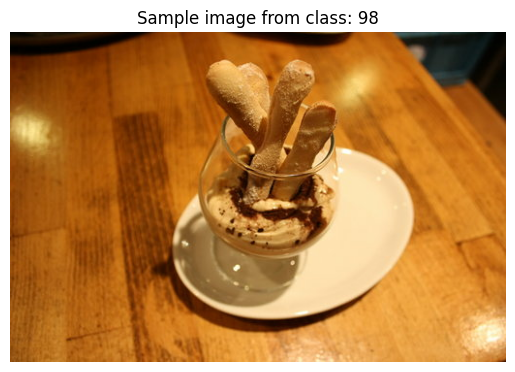

In [24]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = image.numpy() # Convert the image tensor to a NumPy array
plt.imshow(img) # plot the target image
plt.title(f"Sample image from class: {label}")
plt.axis(False); # turn off the axes

Recall that the `ModelCheckpoint` callback gives us the ability to save the model, as a whole in the `SavedModel` format or the weights (patterns) only to a specified directory as it trains.

For example, say we fit a feature extraction transfer learning model for 5 epochs and we check the training curves and see it was still improving and we want to see if fine-tuning for another 5 epochs could help, we can load the checkpoint, unfreeze some (or all) of the base model layers and then continue training.

Let's create a `ModelCheckpoint` callback. To do so, we have to specify a directory to which we would like to save.

In [ ]:
# Setup checkpoint path
checkpoint_path = "101_classes_model_checkpoints_weights/.weights.h5" # note: remember saving directly to Colab is temporary

# Create a ModelCheckpoint callback that saves the model's weights only
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path,
                                                         save_weights_only=True, # set to False to save the entire model
                                                         save_best_only=True, # save only the best model weights instead of a model every epoch
                                                         save_freq="epoch", # save every epoch
                                                         verbose=1)

Checkpoint ready. Now let's create a small data augmentation model with the Sequential API. Because we're working with a reduced sized training set, this will help prevent our model from overfitting on the training data.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
# from tensorflow.keras.layers.experimental import preprocessing

# NEW: Newer versions of TensorFlow (2.10+) can use the tensorflow.keras.layers API directly for data augmentation
data_augmentation = keras.Sequential([
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.2),
  layers.RandomZoom(0.2),
  layers.RandomHeight(0.2),
  layers.RandomWidth(0.2),
  # preprocessing.Rescaling(1./255) # keep for ResNet50V2, remove for EfficientNetV2B0
  ], name ="data_augmentation")

#### Build the first model, `model`.

In [ ]:
# Set up input shape and base model, freezing the base model layers
input_shape = (224, 224, 3)
base_model = tf.keras.applications.efficientnet_v2.EfficientNetV2B0(include_top=False)
base_model.trainable = False

# Create input layer
inputs = layers.Input(shape=input_shape, name="input_layer")

# Add in data augmentation Sequential model as a layer
x = data_augmentation(inputs)

# Give base_model inputs (after augmentation) and don't train it
x = base_model(x, training=False)

# Pool output features of base model
x = layers.GlobalAveragePooling2D(name="global_average_pooling_layer")(x)

# Put a dense layer on as the output
outputs = layers.Dense(len(train_data_10_percent.class_names), activation="softmax", name="output_layer")(x)

# Make a model with inputs and outputs
model = keras.Model(inputs, outputs)

# Compile the model
model.compile(loss="categorical_crossentropy",
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])


In [ ]:
model.summary()

In [ ]:
# Fit the model
history = model.fit(train_data_10_percent,
                    epochs=5,
                    steps_per_epoch=len(train_data_10_percent),
                    validation_data=test_data_100_percent,
                    validation_steps=int(0.25* len(test_data_100_percent)), # validate for less steps
                    # Track model training logs
                    callbacks=[create_tensorboard_callback("transfer_learning_scaling_up", "10_percent_data_aug")])


In [ ]:
# Evaluate model on entire test dataset
results_feature_extraction_model = model.evaluate(test_data_100_percent)
results_feature_extraction_model

In [ ]:
# Check out our model's training curves
plot_loss_curves(history)

#### Let's fine tune the model by unfreezing the last 5 layers of the base model.

In [ ]:
# Unfreeze all of the layers in the base model
base_model.trainable = True

# Refreeze every layer except for the last 5
for layer in base_model.layers[:-5]:
  layer.trainable = False

In [ ]:
# Recompile model with lower learning rate
model.compile(loss='categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(1e-4), # 10x lower learning rate than default
              metrics=['accuracy'])

In [ ]:
# What layers in the model are trainable?
for layer in model.layers:
  print(layer.name, layer.trainable)

In [ ]:
# Check which layers are trainable
for layer_number, layer in enumerate(base_model.layers):
  print(layer_number, layer.name, layer.trainable)

In [ ]:
# Fine-tune for 5 more epochs
fine_tune_epochs = 10 # model has already done 5 epochs, this is the total number of epochs we're after (5+5=10)

history_all_classes_10_percent_fine_tune = model.fit(train_data_10_percent,
                                                     epochs=fine_tune_epochs,
                                                     validation_data=test_data_100_percent,
                                                     validation_steps=int(0.15 * len(test_data_100_percent)), # validate on 15% of the test data
                                                     initial_epoch=history.epoch[-1]) # start from previous last epoch

In [ ]:
# Evaluate fine-tuned model on the whole test dataset
results_all_classes_10_percent_fine_tune = model.evaluate(test_data_100_percent)
results_all_classes_10_percent_fine_tune

In [ ]:
compare_histories(original_history=history,
                 new_history=history_all_classes_10_percent_fine_tune,
                 initial_epochs=5)

## Saving and Loading the Model

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

#### Save the fine-tuned model.

In [ ]:
model.save('/content/drive/MyDrive/Colab_Notebooks/TensorFlow Training/TensorFlow Course - Udemy/TensorFlow Models/101_food_classes_10_percent_feature_extraction_model.keras')

#### Let's reload the model....

In [ ]:
loaded_model = tf.keras.models.load_model('/content/drive/MyDrive/Colab_Notebooks/TensorFlow Training/TensorFlow Course - Udemy/TensorFlow Models/101_food_classes_10_percent_feature_extraction_model.keras')
loaded_model.summary()

In [ ]:
loaded_model.evaluate(test_data_100_percent)

## Making Predictions with the Trained Model

In [ ]:
# Make predictions with model
pred_probs = loaded_model.predict(test_data_100_percent, verbose=1) # set verbosity to see how long it will take

In [ ]:
pred_probs[:1], pred_probs.shape

In [ ]:
# We get one prediction probability per class
print(f"Number of prediction probabilities for sample 0: {len(pred_probs[0])}")
print(f"What prediction probability sample 0 looks like:\n {pred_probs[0]}")
print(f"The class with the highest predicted probability by the model for sample 0: {pred_probs[0].argmax()}")